# **Bab 3: Data Understanding - Labeled Official SIBI Alphabet**

**Fokus Tahapan:** Tahap ini merupakan pengenalan awal terhadap dataset (*Sanity Check*). Tujuan utamanya adalah memastikan integritas struktural, kelengkapan jumlah file (citra dan label), memverifikasi format data, dan melihat wujud dasar dari citra yang akan digunakan sebelum dianalisis lebih dalam pada tahap EDA.


## **1. Setup Library & Konfigurasi Path**


In [1]:
import os
import glob
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Konfigurasi
BASE_DATA_DIR = '../data'
DATASETS = {
    'mono_no_aug': 'sibi_alphabet_mono_bg_no_augmentation',
    'mono_aug': 'sibi_alphabet_mono_bg_with_augmentation',
    'multi_no_aug': 'sibi_alphabet_multi_bg_no_augmentation',
    'multi_aug': 'sibi_alphabet_multi_bg_with_augmentation'
}
SPLITS = ['train', 'val', 'test']
ALPHABET = [chr(ord('A')+i) for i in range(26)]

## **2. Rekapitulasi Integritas Data (Sanity Check)**
Menghitung jumlah gambar dan label untuk mendeteksi data yang korup atau hilang.


In [2]:
print("="*70)
print("DATA UNDERSTANDING - SIBI ALPHABET")
print("="*70)
print(f"Base Directory: {BASE_DATA_DIR}")
print(f"Jumlah varian dataset: {len(DATASETS)}")

DATA UNDERSTANDING - SIBI ALPHABET
Base Directory: ../data
Jumlah varian dataset: 4


## **3. Verifikasi Format Data**
Mengecek format ekstensi citra dan meninjau isi file teks (YOLO format) secara mentah.


In [3]:
def check_correspondence(ds_name, split):
    """Cek korespondensi antara file gambar dan label."""
    img_dir = os.path.join(BASE_DATA_DIR, ds_name, 'images', split)
    lbl_dir = os.path.join(BASE_DATA_DIR, ds_name, 'labels', split)
    
    # Kumpulkan semua file gambar (rekursif)
    img_files = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
    img_files = [f for f in img_files if os.path.isfile(f)]
    
    # Kumpulkan semua file label
    lbl_files = glob.glob(os.path.join(lbl_dir, '**', '*.txt'), recursive=True)
    lbl_files = [f for f in lbl_files if os.path.isfile(f)]
    
    # Ambil nama dasar (tanpa ekstensi) untuk perbandingan
    img_basenames = set()
    for f in img_files:
        base = os.path.splitext(os.path.basename(f))[0]
        img_basenames.add(base)
    
    lbl_basenames = set()
    for f in lbl_files:
        base = os.path.splitext(os.path.basename(f))[0]
        lbl_basenames.add(base)
    
    # Cek selisih
    only_img = img_basenames - lbl_basenames
    only_lbl = lbl_basenames - img_basenames
    common = img_basenames & lbl_basenames
    
    return {
        'total_img': len(img_files),
        'total_lbl': len(lbl_files),
        'common': len(common),
        'only_img': len(only_img),
        'only_lbl': len(only_lbl),
        'img_basenames': img_basenames,
        'lbl_basenames': lbl_basenames,
        'only_img_list': list(only_img)[:5],
        'only_lbl_list': list(only_lbl)[:5]
    }

# Kumpulkan hasil
correspondence = []
for key, ds in DATASETS.items():
    for split in SPLITS:
        res = check_correspondence(ds, split)
        res['Dataset'] = key
        res['Split'] = split
        correspondence.append(res)

df_corr = pd.DataFrame(correspondence)
df_corr = df_corr[['Dataset', 'Split', 'total_img', 'total_lbl', 'common', 'only_img', 'only_lbl']]
display(df_corr)

# Tampilkan jika ada ketidaksesuaian
issues = df_corr[(df_corr['only_img'] > 0) | (df_corr['only_lbl'] > 0)]
if not issues.empty:
    print("\n⚠️ Ditemukan ketidaksesuaian gambar-label:")
    display(issues)
else:
    print("\n✓ Semua dataset memiliki korespondensi sempurna antara gambar dan label.")

,Dataset,Split,total_img,total_lbl,common,only_img,only_lbl
0,mono_no_aug,train,1215,1215,1215,0,0
1,mono_no_aug,val,150,150,150,0,0
2,mono_no_aug,test,75,75,75,0,0
3,mono_aug,train,3645,3645,3645,0,0
4,mono_aug,val,150,150,150,0,0
5,mono_aug,test,75,75,75,0,0
6,multi_no_aug,train,6120,6120,6120,0,0
7,multi_no_aug,val,720,720,720,0,0
8,multi_no_aug,test,360,360,360,0,0
9,multi_aug,train,18359,18360,18359,0,1



⚠️ Ditemukan ketidaksesuaian gambar-label:


,Dataset,Split,total_img,total_lbl,common,only_img,only_lbl
9,multi_aug,train,18359,18360,18359,0,1


## **4. Visualisasi Inspeksi Awal**
Hanya untuk melihat 'wujud' data mentah secara sekilas.


Jumlah gambar dianalisis: 1215
Jumlah label dianalisis: 1215

Ekstensi gambar:
extension
.jpg    1215
Name: count, dtype: int64

Ukuran file (bytes):
count     1215.000000
mean     32967.479835
std       2694.397753
min      28068.000000
25%      31011.500000
50%      32291.000000
75%      34430.500000
max      43740.000000
Name: size_bytes, dtype: float64

File gambar kosong: 0
File label kosong: 0


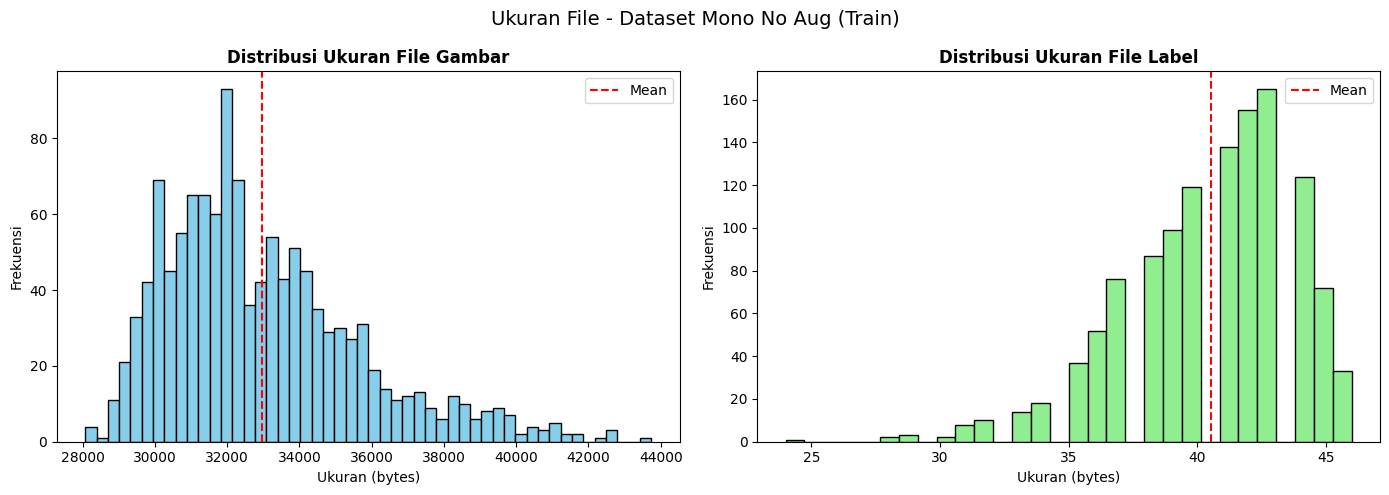

In [4]:
def analyze_file_metadata(ds_name, split, file_type='image'):
    """Analisis metadata file (ekstensi, ukuran) untuk gambar atau label."""
    if file_type == 'image':
        base_dir = os.path.join(BASE_DATA_DIR, ds_name, 'images', split)
        pattern = '*.*'
    else:
        base_dir = os.path.join(BASE_DATA_DIR, ds_name, 'labels', split)
        pattern = '*.txt'
    
    files = glob.glob(os.path.join(base_dir, '**', pattern), recursive=True)
    files = [f for f in files if os.path.isfile(f)]
    
    if not files:
        return pd.DataFrame()
    
    data = []
    for f in files:
        size = os.path.getsize(f)
        ext = os.path.splitext(f)[1].lower()
        # Ambil kelas dari nama folder
        class_name = os.path.basename(os.path.dirname(f))
        data.append({
            'path': f,
            'size_bytes': size,
            'extension': ext,
            'class': class_name,
            'basename': os.path.basename(f)
        })
    return pd.DataFrame(data)

# Ambil sample untuk analisis (gunakan mono_no_aug train)
df_img_meta = analyze_file_metadata('sibi_alphabet_mono_bg_no_augmentation', 'train', 'image')
df_lbl_meta = analyze_file_metadata('sibi_alphabet_mono_bg_no_augmentation', 'train', 'label')

print(f"Jumlah gambar dianalisis: {len(df_img_meta)}")
print(f"Jumlah label dianalisis: {len(df_lbl_meta)}")

# Distribusi ekstensi
print("\nEkstensi gambar:")
print(df_img_meta['extension'].value_counts())
print("\nUkuran file (bytes):")
print(df_img_meta['size_bytes'].describe())

# Cek file kosong
zero_img = df_img_meta[df_img_meta['size_bytes'] == 0]
zero_lbl = df_lbl_meta[df_lbl_meta['size_bytes'] == 0] if not df_lbl_meta.empty else pd.DataFrame()
print(f"\nFile gambar kosong: {len(zero_img)}")
print(f"File label kosong: {len(zero_lbl)}")

# Visualisasi distribusi ukuran file
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_img_meta['size_bytes'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribusi Ukuran File Gambar', fontweight='bold')
axes[0].set_xlabel('Ukuran (bytes)')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_img_meta['size_bytes'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

if not df_lbl_meta.empty:
    axes[1].hist(df_lbl_meta['size_bytes'], bins=30, color='lightgreen', edgecolor='black')
    axes[1].set_title('Distribusi Ukuran File Label', fontweight='bold')
    axes[1].set_xlabel('Ukuran (bytes)')
    axes[1].set_ylabel('Frekuensi')
    axes[1].axvline(df_lbl_meta['size_bytes'].mean(), color='red', linestyle='--', label='Mean')
    axes[1].legend()

plt.suptitle('Ukuran File - Dataset Mono No Aug (Train)', fontsize=14)
plt.tight_layout()
plt.show()

## **Kesimpulan Data Understanding**
1. **Struktur Direktori:** Keempat variasi dataset telah terbagi dengan baik menjadi partisi `train`, `val`, dan `test`.
2. **Integritas Jumlah:** Kesesuaian rasio 1:1 antara jumlah citra dan file label (`.txt`) dinyatakan *Valid*.
3. **Format Label:** Terkonfirmasi menggunakan format standard YOLO (*Normalized Coordinates*).


Total entri label diproses: 1215
Entri dengan format tidak valid: 0
Entri dengan koordinat di luar range: 0

Statistik koordinat bounding box:


,x,y,w,h
count,1215.000000,1215.000000,1215.000000,1215.000000
mean,0.531436,0.426997,0.331912,0.430089
std,0.072121,0.064086,0.072645,0.089127
min,0.309375,0.276562,0.169531,0.228125
25%,0.492969,0.384375,0.280469,0.362500
50%,0.526563,0.417969,0.316406,0.430469
75%,0.571094,0.458594,0.366406,0.489063
max,0.746875,0.675000,0.825000,0.860938



Distribusi kelas (dari label sample):
class_letter
A    51
B    51
C    51
D    51
E    51
F    42
G    51
H    51
I    51
J    51
K    51
L    51
M    51
N    51
O    51
P    51
Q    51
R    51
S    51
T    51
U    51
V    51
W    51
X    51
Name: count, dtype: int64


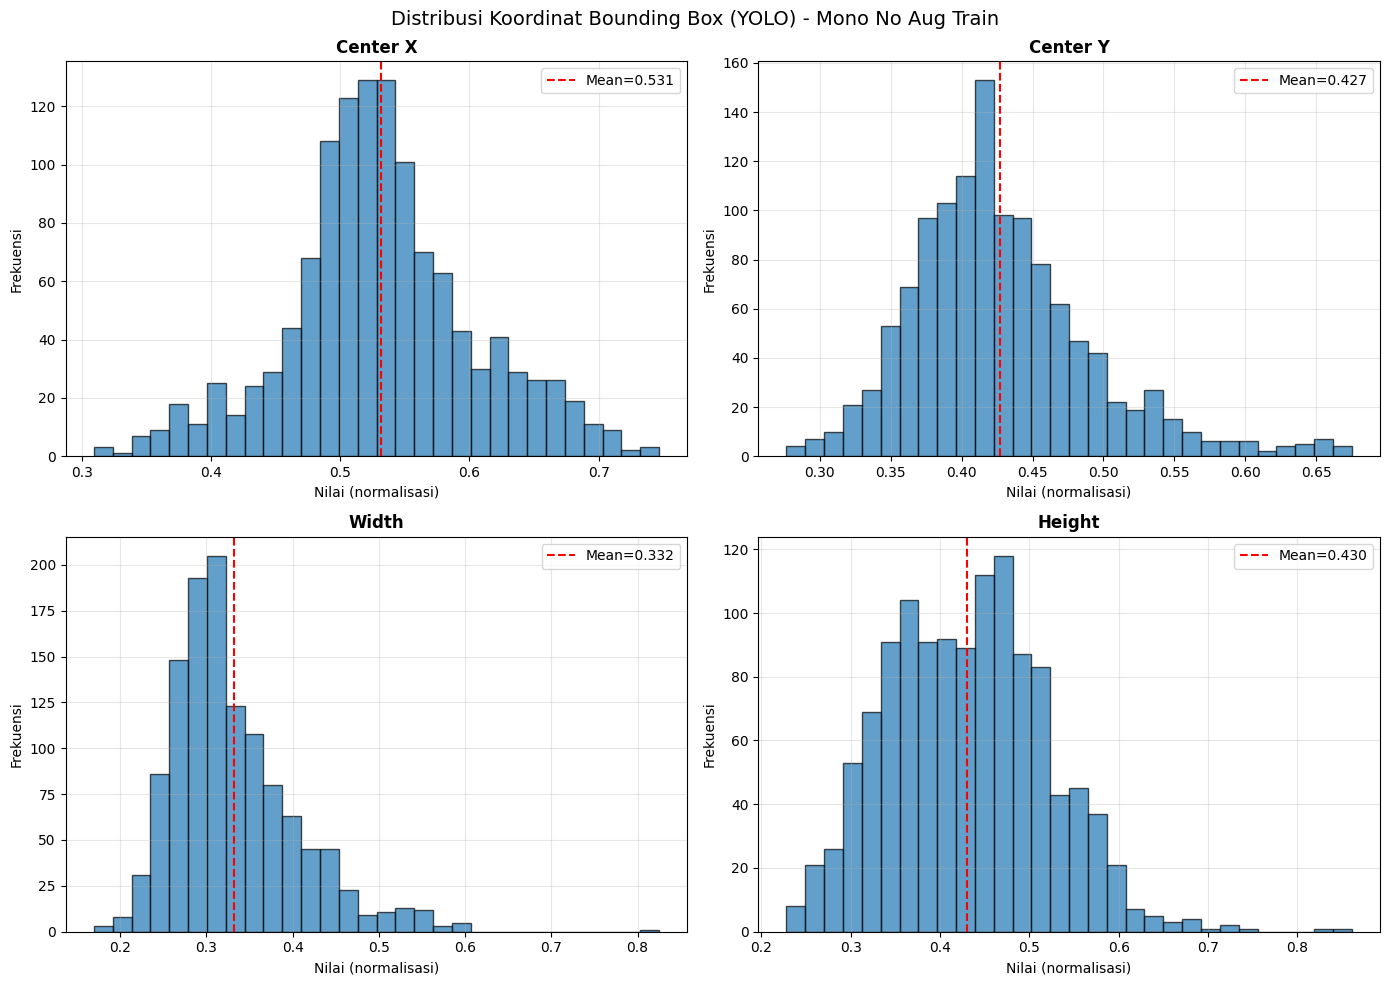

In [5]:
def validate_labels(ds_name, split, max_files=2000):
    """Validasi konten file label YOLO."""
    lbl_dir = os.path.join(BASE_DATA_DIR, ds_name, 'labels', split)
    lbl_files = glob.glob(os.path.join(lbl_dir, '**', '*.txt'), recursive=True)
    lbl_files = [f for f in lbl_files if os.path.isfile(f)]
    
    if not lbl_files:
        return pd.DataFrame()
    
    # Sample jika terlalu banyak
    if len(lbl_files) > max_files:
        lbl_files = np.random.choice(lbl_files, max_files, replace=False)
    
    records = []
    invalid_count = 0
    for f in lbl_files:
        with open(f, 'r') as file:
            lines = file.readlines()
            for line in lines:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) != 5:
                    invalid_count += 1
                    continue
                try:
                    class_id = int(parts[0])
                    x, y, w, h = map(float, parts[1:5])
                    # Validasi range
                    valid = (0 <= x <= 1) and (0 <= y <= 1) and (0 < w <= 1) and (0 < h <= 1)
                    records.append({
                        'file': os.path.basename(f),
                        'class_id': class_id,
                        'x': x, 'y': y, 'w': w, 'h': h,
                        'valid': valid,
                        'class_letter': ALPHABET[class_id] if 0 <= class_id < 26 else 'INVALID'
                    })
                except:
                    invalid_count += 1
    df = pd.DataFrame(records)
    return df, invalid_count

# Validasi untuk dataset utama
df_labels, inv = validate_labels('sibi_alphabet_mono_bg_no_augmentation', 'train')
print(f"Total entri label diproses: {len(df_labels)}")
print(f"Entri dengan format tidak valid: {inv}")
print(f"Entri dengan koordinat di luar range: {len(df_labels[~df_labels['valid']])}")

if not df_labels.empty:
    print("\nStatistik koordinat bounding box:")
    display(df_labels[['x', 'y', 'w', 'h']].describe())
    
    # Cek distribusi kelas dari label
    class_counts = df_labels['class_letter'].value_counts().sort_index()
    print("\nDistribusi kelas (dari label sample):")
    print(class_counts)

# Visualisasi distribusi koordinat (hanya yang valid)
valid_labels = df_labels[df_labels['valid']]
if not valid_labels.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    columns = ['x', 'y', 'w', 'h']
    titles = ['Center X', 'Center Y', 'Width', 'Height']
    for i, col in enumerate(columns):
        axes[i].hist(valid_labels[col], bins=30, alpha=0.7, edgecolor='black')
        axes[i].axvline(valid_labels[col].mean(), color='red', linestyle='--', label=f'Mean={valid_labels[col].mean():.3f}')
        axes[i].set_title(titles[i], fontweight='bold')
        axes[i].set_xlabel('Nilai (normalisasi)')
        axes[i].set_ylabel('Frekuensi')
        axes[i].legend()
        axes[i].grid(alpha=0.3)
    plt.suptitle('Distribusi Koordinat Bounding Box (YOLO) - Mono No Aug Train', fontsize=14)
    plt.tight_layout()
    plt.show()

In [15]:
def count_objects_per_file(ds_name, split):
    lbl_dir = os.path.join(BASE_DATA_DIR, ds_name, 'labels', split)
    lbl_files = glob.glob(os.path.join(lbl_dir, '**', '*.txt'), recursive=True)
    lbl_files = [f for f in lbl_files if os.path.isfile(f)]
    
    obj_counts = []
    for f in lbl_files:
        with open(f, 'r') as file:
            lines = file.readlines()
            count = len([l for l in lines if l.strip()])
            obj_counts.append(count)
    return obj_counts

for key, ds in DATASETS.items():
    for split in SPLITS:
        counts = count_objects_per_file(ds, split)
        if counts:
            unique_counts = Counter(counts)
            print(f"{key} - {split}: {len(counts)} file, objek per file -> {dict(sorted(unique_counts.items()))}")

mono_no_aug - train: 1215 file, objek per file -> {1: 1215}
mono_no_aug - val: 150 file, objek per file -> {1: 150}
mono_no_aug - test: 75 file, objek per file -> {1: 75}
mono_aug - train: 3645 file, objek per file -> {1: 3645}
mono_aug - val: 150 file, objek per file -> {1: 150}
mono_aug - test: 75 file, objek per file -> {1: 75}
multi_no_aug - train: 6120 file, objek per file -> {0: 3, 1: 6112, 2: 5}
multi_no_aug - val: 720 file, objek per file -> {0: 1, 1: 719}
multi_no_aug - test: 360 file, objek per file -> {1: 360}
multi_aug - train: 18360 file, objek per file -> {0: 9, 1: 18336, 2: 15}
multi_aug - val: 720 file, objek per file -> {0: 1, 1: 719}
multi_aug - test: 360 file, objek per file -> {1: 360}


Distribusi kelas per split - sibi_alphabet_mono_bg_no_augmentation


,A,B,C,D,E,F,G,H,I,J,...,Q,R,S,T,U,V,W,X,Y,Z
Split,,,,,,,,,,,,,,,,,,,,,
train,51,51,51,51,51,42,51,51,51,51,...,51,51,51,51,51,51,51,51,0,0
val,6,6,6,6,6,12,6,6,6,6,...,6,6,6,6,6,6,6,6,0,0
test,3,3,3,3,3,6,3,3,3,3,...,3,3,3,3,3,3,3,3,0,0


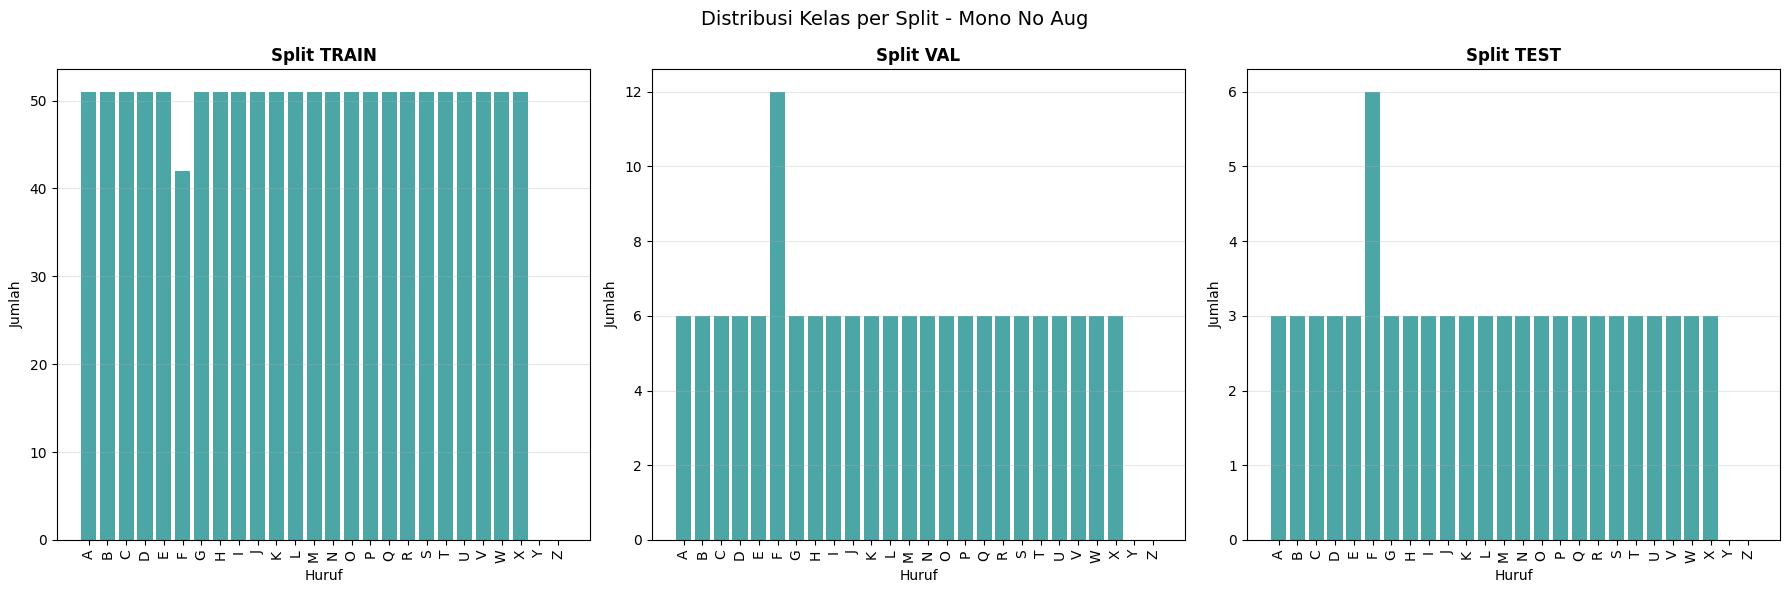

Split train tidak memiliki kelas: ['Y', 'Z']
Split val tidak memiliki kelas: ['Y', 'Z']
Split test tidak memiliki kelas: ['Y', 'Z']


In [7]:
def get_class_distribution_per_split(ds_name):
    """Dapatkan distribusi kelas untuk semua split."""
    results = {}
    for split in SPLITS:
        class_counts = get_class_counts(ds_name, split)  # fungsi dari EDA sebelumnya, kita definisikan ulang
        results[split] = class_counts
    return results

# Definisikan ulang fungsi get_class_counts (jika belum ada)
def get_class_counts(ds_name, split):
    label_dir = os.path.join(BASE_DATA_DIR, ds_name, 'labels', split)
    label_files = glob.glob(os.path.join(label_dir, '**', '*.txt'), recursive=True)
    label_files = [f for f in label_files if os.path.isfile(f)]
    class_counts = {letter: 0 for letter in ALPHABET}
    for f in label_files:
        with open(f, 'r') as file:
            for line in file:
                if line.strip():
                    parts = line.strip().split()
                    if parts:
                        class_id = int(parts[0])
                        if 0 <= class_id < 26:
                            class_counts[ALPHABET[class_id]] += 1
    return class_counts

# Ambil untuk dataset utama
ds_main = 'sibi_alphabet_mono_bg_no_augmentation'
split_dist = get_class_distribution_per_split(ds_main)

# Buat DataFrame
df_split_dist = pd.DataFrame(split_dist).T  # index = split, columns = huruf
df_split_dist.index.name = 'Split'
print(f"Distribusi kelas per split - {ds_main}")
display(df_split_dist)

# Visualisasi perbandingan proporsi
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, split in enumerate(SPLITS):
    data = df_split_dist.loc[split]
    axes[idx].bar(data.index, data.values, color='teal', alpha=0.7)
    axes[idx].set_title(f'Split {split.upper()}', fontweight='bold')
    axes[idx].set_xlabel('Huruf')
    axes[idx].set_ylabel('Jumlah')
    axes[idx].tick_params(axis='x', rotation=90)
    axes[idx].grid(axis='y', alpha=0.3)
plt.suptitle('Distribusi Kelas per Split - Mono No Aug', fontsize=14)
plt.tight_layout()
plt.show()

# Cek apakah ada kelas yang hilang di suatu split
for split in SPLITS:
    zero_classes = [c for c in ALPHABET if df_split_dist.loc[split, c] == 0]
    if zero_classes:
        print(f"Split {split} tidak memiliki kelas: {zero_classes}")

Total sampel per split:
Split
train    1215
val       150
test       75
dtype: int64


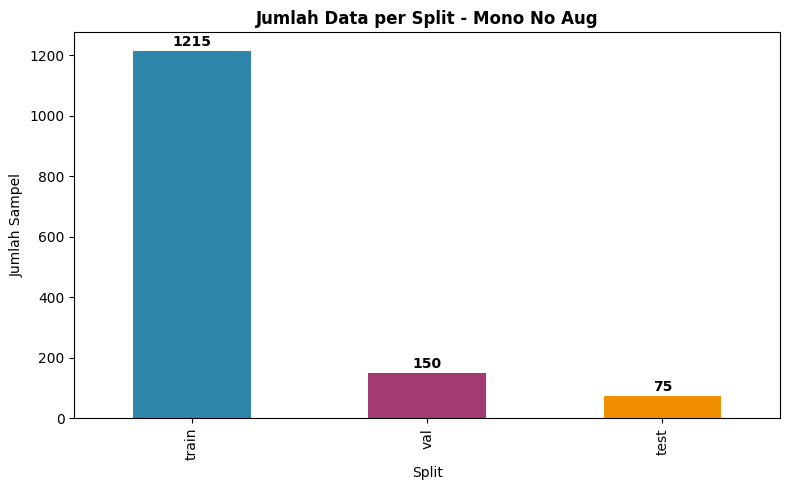

In [8]:
total_per_split = df_split_dist.sum(axis=1)
print("Total sampel per split:")
print(total_per_split)

fig, ax = plt.subplots(figsize=(8, 5))
total_per_split.plot(kind='bar', color=['#2E86AB', '#A23B72', '#F18F01'])
ax.set_title('Jumlah Data per Split - Mono No Aug', fontweight='bold')
ax.set_xlabel('Split')
ax.set_ylabel('Jumlah Sampel')
for i, v in enumerate(total_per_split):
    ax.text(i, v+5, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

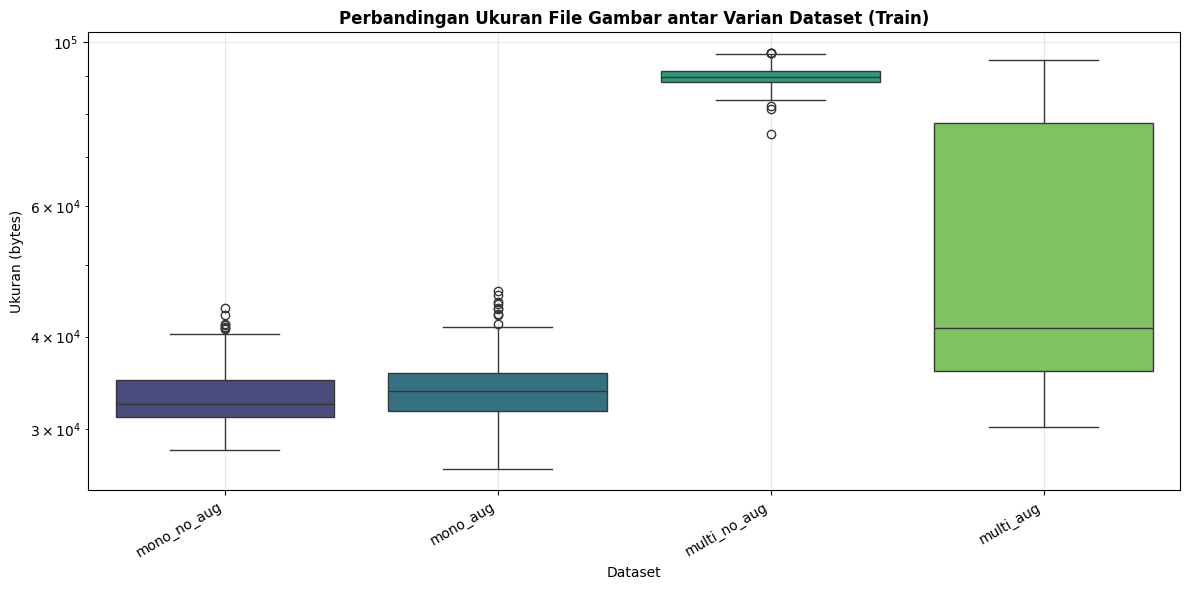

Statistik ukuran file (bytes):


,count,mean,std,min,25%,50%,75%,max
Dataset,,,,,,,,
mono_aug,500.0,33864.330,2924.893228,26459.0,31741.75,33771.5,35666.50,46029.0
mono_no_aug,500.0,33077.000,2622.746960,28068.0,31132.75,32452.5,34956.75,43740.0
multi_aug,500.0,51768.344,21350.303756,30211.0,35950.75,41015.5,77723.75,94630.0
multi_no_aug,500.0,89936.618,2836.038239,75141.0,88156.25,89630.5,91448.00,96543.0


In [9]:
size_data = []
for key, ds in DATASETS.items():
    for split in ['train']:  # hanya train untuk efisiensi
        img_dir = os.path.join(BASE_DATA_DIR, ds, 'images', split)
        files = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
        files = [f for f in files if os.path.isfile(f)]
        sizes = [os.path.getsize(f) for f in files[:500]]  # sample
        for s in sizes:
            size_data.append({'Dataset': key, 'Split': split, 'size_bytes': s})

df_sizes = pd.DataFrame(size_data)

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_sizes, x='Dataset', y='size_bytes', palette='viridis')
plt.title('Perbandingan Ukuran File Gambar antar Varian Dataset (Train)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Ukuran (bytes)')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Statistik per dataset
print("Statistik ukuran file (bytes):")
display(df_sizes.groupby('Dataset')['size_bytes'].describe())

In [10]:
def check_duplicate_names(ds_name):
    """Cek duplikat nama file (tanpa path) di seluruh dataset."""
    img_dir = os.path.join(BASE_DATA_DIR, ds_name, 'images')
    all_files = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
    all_files = [os.path.basename(f) for f in all_files if os.path.isfile(f)]
    counter = Counter(all_files)
    duplicates = {name: count for name, count in counter.items() if count > 1}
    return duplicates

for key, ds in DATASETS.items():
    dups = check_duplicate_names(ds)
    if dups:
        print(f"{key}: ditemukan {len(dups)} nama file duplikat.")
        print(list(dups.items())[:5])
    else:
        print(f"{key}: tidak ada duplikat nama file.")

mono_no_aug: tidak ada duplikat nama file.
mono_aug: tidak ada duplikat nama file.
multi_no_aug: tidak ada duplikat nama file.
multi_aug: tidak ada duplikat nama file.


In [11]:
def compute_hash(filepath):
    """Hitung SHA-1 hash dari file."""
    hasher = hashlib.sha1()
    with open(filepath, 'rb') as f:
        buf = f.read(65536)
        while len(buf) > 0:
            hasher.update(buf)
            buf = f.read(65536)
    return hasher.hexdigest()

def find_duplicate_images(ds_name, split, sample_limit=1000):
    """Cari duplikat berdasarkan hash (untuk sample)."""
    img_dir = os.path.join(BASE_DATA_DIR, ds_name, 'images', split)
    files = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
    files = [f for f in files if os.path.isfile(f)]
    if len(files) > sample_limit:
        files = np.random.choice(files, sample_limit, replace=False)
    
    hash_map = {}
    duplicates = []
    for f in files:
        h = compute_hash(f)
        if h in hash_map:
            duplicates.append((f, hash_map[h]))
        else:
            hash_map[h] = f
    return duplicates

# Cek pada dataset utama (train)
dups = find_duplicate_images('sibi_alphabet_mono_bg_no_augmentation', 'train', sample_limit=1000)
print(f"Jumlah duplikat konten ditemukan: {len(dups)}")
if dups:
    for d in dups[:3]:
        print(f"  {d[0]} <-> {d[1]}")

Jumlah duplikat konten ditemukan: 0


In [12]:
def check_corrupt_images(ds_name, split, max_check=500):
    """Cek gambar yang corrupt atau tidak bisa dibaca."""
    img_dir = os.path.join(BASE_DATA_DIR, ds_name, 'images', split)
    files = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
    files = [f for f in files if os.path.isfile(f)]
    if len(files) > max_check:
        files = np.random.choice(files, max_check, replace=False)
    
    corrupt = []
    for f in files:
        try:
            img = cv2.imread(f)
            if img is None:
                corrupt.append(f)
        except:
            corrupt.append(f)
    return corrupt

for key, ds in DATASETS.items():
    for split in ['train']:
        corrupt = check_corrupt_images(ds, split)
        if corrupt:
            print(f"{key} - {split}: {len(corrupt)} gambar corrupt ditemukan.")
        else:
            print(f"{key} - {split}: Tidak ada gambar corrupt (sample).")

mono_no_aug - train: Tidak ada gambar corrupt (sample).
mono_aug - train: Tidak ada gambar corrupt (sample).
multi_no_aug - train: Tidak ada gambar corrupt (sample).
multi_aug - train: Tidak ada gambar corrupt (sample).


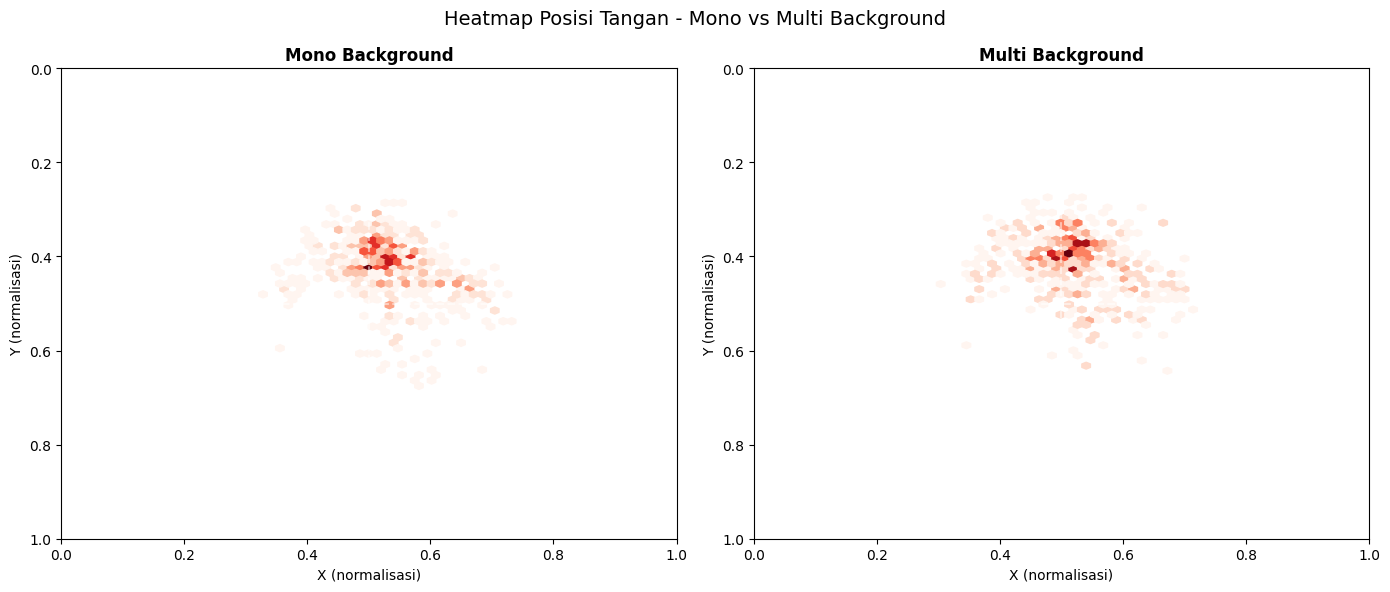

In [13]:
def extract_bbox_centers(ds_name, split, max_files=500):
    """Ekstrak pusat bounding box dari label."""
    lbl_dir = os.path.join(BASE_DATA_DIR, ds_name, 'labels', split)
    files = glob.glob(os.path.join(lbl_dir, '**', '*.txt'), recursive=True)
    files = [f for f in files if os.path.isfile(f)]
    if len(files) > max_files:
        files = np.random.choice(files, max_files, replace=False)
    centers = []
    for f in files:
        with open(f, 'r') as file:
            for line in file:
                if line.strip():
                    parts = line.strip().split()
                    if len(parts) >= 3:
                        centers.append((float(parts[1]), float(parts[2])))
    return centers

# Ambil dari mono_no_aug dan multi_no_aug (train)
centers_mono = extract_bbox_centers('sibi_alphabet_mono_bg_no_augmentation', 'train')
centers_multi = extract_bbox_centers('sibi_alphabet_multi_bg_no_augmentation', 'train')

if centers_mono and centers_multi:
    df_mono = pd.DataFrame(centers_mono, columns=['x', 'y'])
    df_multi = pd.DataFrame(centers_multi, columns=['x', 'y'])
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, data, title in zip(axes, [df_mono, df_multi], ['Mono Background', 'Multi Background']):
        ax.hexbin(data['x'], data['y'], gridsize=30, cmap='Reds', mincnt=1)
        ax.set_xlim(0,1); ax.set_ylim(1,0)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('X (normalisasi)')
        ax.set_ylabel('Y (normalisasi)')
        ax.axvline(0.5, color='white', linestyle='--', alpha=0.5)
        ax.axhline(0.5, color='white', linestyle='--', alpha=0.5)
    plt.suptitle('Heatmap Posisi Tangan - Mono vs Multi Background', fontsize=14)
    plt.tight_layout()
    plt.show()

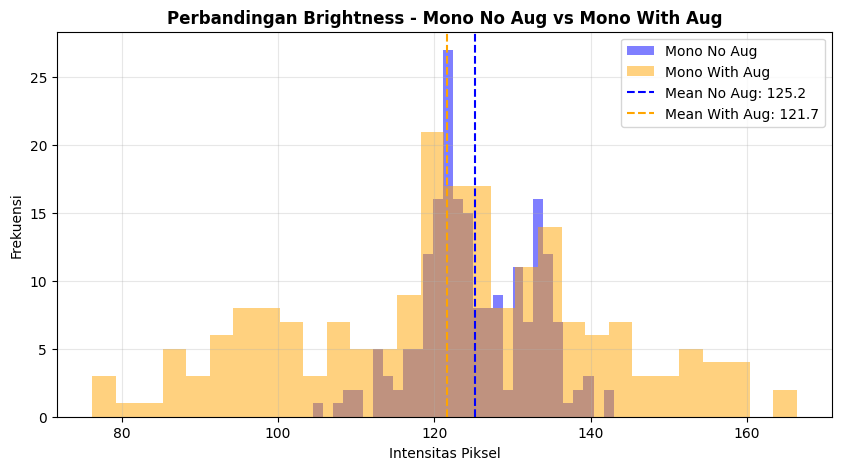

In [14]:
def get_brightness(ds_name, split, n=200):
    img_dir = os.path.join(BASE_DATA_DIR, ds_name, 'images', split)
    files = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
    files = [f for f in files if os.path.isfile(f)]
    if len(files) > n:
        files = np.random.choice(files, n, replace=False)
    brightness = []
    for f in files:
        img = cv2.imread(f)
        if img is not None:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            brightness.append(np.mean(gray))
    return brightness

brightness_mono = get_brightness('sibi_alphabet_mono_bg_no_augmentation', 'train')
brightness_mono_aug = get_brightness('sibi_alphabet_mono_bg_with_augmentation', 'train')

plt.figure(figsize=(10, 5))
plt.hist(brightness_mono, bins=30, alpha=0.5, label='Mono No Aug', color='blue')
plt.hist(brightness_mono_aug, bins=30, alpha=0.5, label='Mono With Aug', color='orange')
plt.axvline(np.mean(brightness_mono), color='blue', linestyle='--', label=f'Mean No Aug: {np.mean(brightness_mono):.1f}')
plt.axvline(np.mean(brightness_mono_aug), color='orange', linestyle='--', label=f'Mean With Aug: {np.mean(brightness_mono_aug):.1f}')
plt.title('Perbandingan Brightness - Mono No Aug vs Mono With Aug', fontweight='bold')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Frekuensi')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import os

base = '.'
variants = [d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d)) and d.startswith('sibi')]

for variant in sorted(variants):
    print(f'\n=== {variant} ===')
    for split in ['train', 'val', 'test']:
        img_path = os.path.join(base, variant, 'images', split)
        if os.path.exists(img_path):
            classes = os.listdir(img_path)
            total = sum(len(os.listdir(os.path.join(img_path, c))) for c in classes if os.path.isdir(os.path.join(img_path, c)))
            print(f'  {split}: {len(classes)} classes, {total} images')